##Contents


0.   Learning Objectives
1.   Tutorial Details
2.   Problem Statement Description
3.   Import Packages
4.   Load and Prepare the Dataset
5.   Peform Exploratory Data Analysis (EDA)
6.   Model Building: Training and Testing
7.   Results and Interpretation
8.   Conclusion
9.   Try it yourself excercise
10.  Summary

# 0. Learning Objectives


*   Application of **Support Vector Machines** on a public dataset
*   Use of various **kernels** for **Support Vector Classifiers**
*   Exercise: Application of **Support Vector Regression** on a public dataset



#1. Tutorial Details

*   **ML Topic(s) Covered**: Support Vector Machines (SVM)
*   **Problem Statement**: The Breast Cancer Wisconsin (Diagnostic) dataset includes measurements of tumors for 569 patients and their diagnosis as malignant (is/can spread over multiple locations)*  or benign (is/can be concentrated to a small/specific location)*. The goal is to develop a SVM-based binary classification model that predicts the diagnosis based on the tumor features.
*   Approximate model training time: 5-10 min.


*Note: These are lame descriptions for easy understanding. For precise definitions, refer to a medical resource.

#2. Problem Statement Description

*   **Objective**: To predict whether a given tumor is malignant or benign based on the features using support vector machines.
*   **Data Description**: The Breast Cancer Wisconsin (Diagnostic) Data Set was first introduced by Dr. William H. Wolberg in 1992 and is a dataset of breast cancer patients with 30 features, including patient and tumor characteristics, such as radius, texture, and perimeter. The dataset includes 569 instances, with 212 malignant (likely to cause death if not controlled) and 357 benign (not dangerous) cases.


*   More information is available here: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)

# 3. Import Packages

Package versions

*   pandas==1.4.4
*   numpy==1.22.4
*   matplotlib==3.7.1
*   sklearn==1.2.2

In [1]:
# Pandas contains functions data manipulation and analysis
import pandas as pd

#Numpy combines high-level mathematical operating capabilites with large, multi-dimensional arrays and matrices
import numpy as np

# Matplotlib is a data visualization library containing functions for static, animated, and interactive 2D and 3D plots
import matplotlib.pyplot as plt

# Scikit-learn (sklearn) contains functions of machine learning models, evaluation metrics, helper functions and datasets
import sklearn

# 4. Load and Prepare the Dataset

In [2]:
# Load the Breast Cancer Wisconsin (Diagnostic) dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

# Convert the data to a pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target_names[data.target]

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


Here, we have 30 features followed by 1 target variable.

In [3]:
#Print the shape of the data
df.shape

(569, 31)



There are 31 columns (30 features and 1 target variable) and 569 rows in the imported data.


In [4]:
#Check information about the data including information about the rows and columns, number of non-null values per column, datatype of each column  and total memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

*   All features are float values.
*   The target variable is of object (categorical type). This needs to be converted to some numerical value.
*   There is no null value.

Below, let us separate the feature (independent variable) and the target variable (dependent variable) in the data.

In [5]:
features = df.iloc[:, :-1]
predictions = df.iloc[:, -1] #Last column contains the target variable

In [6]:
#Print a fews rows of independent variables
features.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
features.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


The description of the data shows that feature scaling is necessary.

In [8]:
#Print a fews rows of dependent variables
predictions.head()

0    malignant
1    malignant
2    malignant
3    malignant
4    malignant
Name: target, dtype: object

### Feature Scaling
Let's perform feature standardization

In [9]:
# Perform feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #Used to perform standardization of the features
features_scaled = scaler.fit_transform(features)
features_scaled = pd.DataFrame(features_scaled, columns = features.columns)
features_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [10]:
features_scaled.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,...,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02
mean,-3.153111e-15,-6.568462e-15,-6.993039e-16,-8.553985e-16,6.081447e-15,-1.136369e-15,-2.997017e-16,1.023981e-15,-1.860648e-15,-1.504752e-15,...,-2.297713e-15,1.742016e-15,-1.198807e-15,6.118909e-16,-5.094929e-15,-2.122887e-15,6.118909e-16,-1.998011e-16,-2.422589e-15,2.497514e-15
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873e+00,-1.261820e+00,-2.744117e+00,-1.819865e+00,...,-1.726901e+00,-2.223994e+00,-1.693361e+00,-1.222423e+00,-2.682695e+00,-1.443878e+00,-1.305831e+00,-1.745063e+00,-2.160960e+00,-1.601839e+00
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-7.437479e-01,-7.379438e-01,-7.032397e-01,-7.226392e-01,...,-6.749213e-01,-7.486293e-01,-6.895783e-01,-6.421359e-01,-6.912304e-01,-6.810833e-01,-7.565142e-01,-7.563999e-01,-6.418637e-01,-6.919118e-01
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02,-2.219405e-01,-3.422399e-01,-3.977212e-01,-7.162650e-02,-1.782793e-01,...,-2.690395e-01,-4.351564e-02,-2.859802e-01,-3.411812e-01,-4.684277e-02,-2.695009e-01,-2.182321e-01,-2.234689e-01,-1.274095e-01,-2.164441e-01
75%,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01,4.938569e-01,5.260619e-01,6.469351e-01,5.307792e-01,4.709834e-01,...,5.220158e-01,6.583411e-01,5.402790e-01,3.575891e-01,5.975448e-01,5.396688e-01,5.311411e-01,7.125100e-01,4.501382e-01,4.507624e-01
max,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00,4.568425e+00,4.243589e+00,3.927930e+00,4.484751e+00,4.910919e+00,...,4.094189e+00,3.885905e+00,4.287337e+00,5.930172e+00,3.955374e+00,5.112877e+00,4.700669e+00,2.685877e+00,6.046041e+00,6.846856e+00


Now the range of each feature has been drastically reduced to vary around zero.

Below, let us divided into the training and testing data.

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features_scaled, predictions, test_size=0.2, random_state=42, shuffle=True)
#20% of the total data is kept as test data

# 5.   Peform Exploratory Data Analysis (EDA)

### Exploratory data analysis (EDA) is a crucial step in understanding and analyzing any dataset.

### Henceforth, all the analysis will be performed on the train dataset only. Assume that we do not possess the test data.

In [12]:
Train_data = pd.concat([X_train, y_train], axis = 'columns') #Join along the columns
Train_data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
68,-1.447987,-0.456023,-1.366651,-1.150124,0.728714,0.700428,2.814833,-0.133333,1.093024,2.503828,...,-0.492965,-1.243893,-0.977194,0.693984,1.159269,4.700669,0.919592,2.147190,1.859432,benign
181,1.977508,1.694187,2.089619,1.866047,1.262455,3.389643,2.007548,2.596960,2.129892,1.585220,...,1.270634,2.062335,2.124291,0.733436,3.207003,1.946890,2.675218,1.936879,2.463465,malignant
63,-1.407089,-1.263516,-1.349763,-1.120545,-1.362838,-0.318972,-0.363081,-0.699511,1.932741,0.968562,...,-1.049890,-1.241212,-1.002860,-1.490797,-0.550038,-0.635617,-0.970486,0.616770,0.052877,benign
248,-0.987600,1.380033,-0.986877,-0.875668,0.014925,-0.606466,-0.816190,-0.845247,0.311723,0.069801,...,1.549097,-0.872165,-0.746907,0.768505,-0.728158,-0.766109,-0.810759,0.822228,-0.137199,benign
60,-1.123927,-1.026155,-1.129395,-0.975496,1.212639,-0.449737,-0.978777,-0.929077,3.400421,0.964310,...,-1.339752,-1.114026,-0.900022,-0.213419,-0.989865,-1.201820,-1.352369,1.061659,-0.207578,benign


In [13]:
#Print summary statistics
Train_data.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,...,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000,455.000000
mean,-0.002743,-0.024345,-0.003575,-0.001455,-0.043856,-0.013677,0.001241,-0.016489,-0.002307,-0.005790,...,-0.007059,-0.023047,-0.004709,-0.006322,-0.036667,-0.009690,0.011543,-0.006456,0.006902,-0.004321
std,1.004222,0.992728,1.001829,1.009495,0.990837,0.994394,0.997717,0.981724,1.003546,1.022052,...,0.996329,0.987665,0.994092,0.997919,1.011842,0.986107,1.004592,0.994694,1.021648,0.989056
min,-1.827998,-2.229249,-1.814389,-1.377937,-3.112085,-1.610136,-1.114873,-1.261820,-2.353466,-1.819865,...,-1.572003,-2.223994,-1.571835,-1.154919,-2.682695,-1.443878,-1.305831,-1.745063,-2.160960,-1.601839
25%,-0.687965,-0.725963,-0.694839,-0.667195,-0.749748,-0.785557,-0.746761,-0.737170,-0.705065,-0.730436,...,-0.665603,-0.754329,-0.685259,-0.640114,-0.787669,-0.695396,-0.746679,-0.771626,-0.656424,-0.714632
50%,-0.234963,-0.141869,-0.246689,-0.293480,-0.123848,-0.253400,-0.342240,-0.400043,-0.071627,-0.186785,...,-0.269040,-0.074456,-0.285682,-0.341005,-0.064377,-0.280951,-0.219671,-0.243568,-0.119321,-0.215336
75%,0.458032,0.534144,0.485260,0.320561,0.582825,0.510913,0.546778,0.644227,0.534430,0.468148,...,0.443324,0.653456,0.517940,0.265299,0.599737,0.555572,0.551770,0.707942,0.447712,0.450208
max,3.971288,4.651889,3.976130,5.250529,4.770911,3.924075,4.243589,3.927930,4.484751,4.910919,...,4.094189,3.885905,4.287337,5.930172,3.771263,4.348873,4.700669,2.685877,6.046041,4.935010


It is difficult for us to explore each column through statistics. We will utilize box plots in such a case.

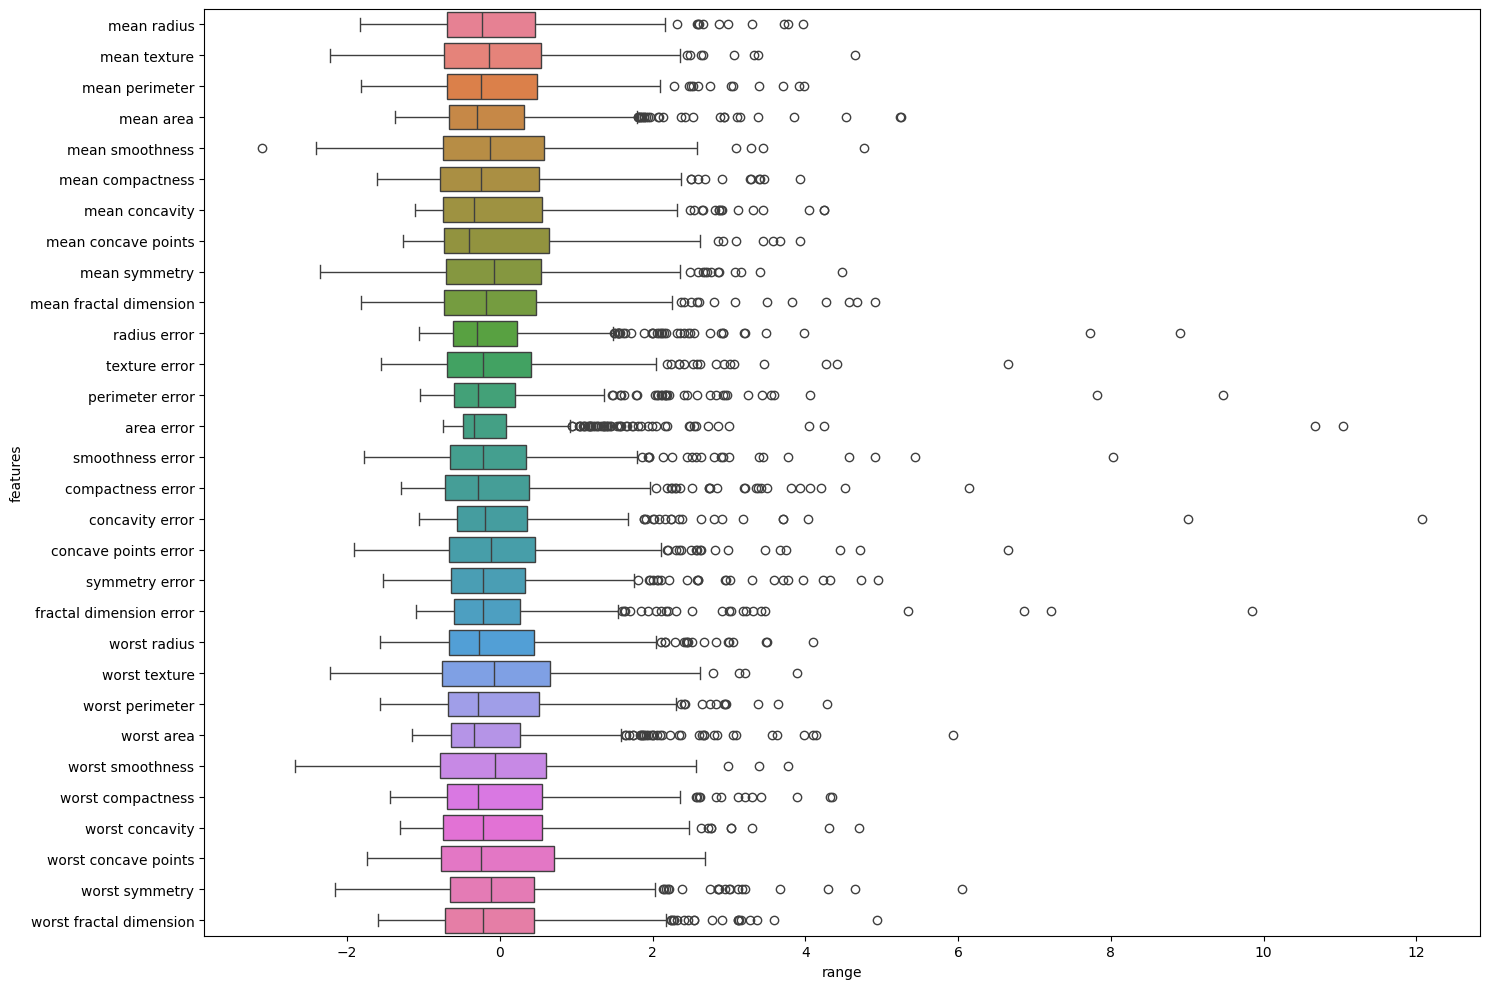

In [14]:
# Seaborn is a data visualization library based on matplotlib
import seaborn as sns
fig, ax = plt.subplots(figsize=(15,10))
sns.boxplot(data=X_train, orient="h").set(xlabel= 'range', ylabel='features')
plt.tight_layout()

### Correlation Analysis

In [ ]:
#Perform correlation analysis between numerical features
corr_mat = Train_data.corr(method ='pearson') #Pearson correlation is used
corr_mat

<ipython-input-44-9a44fb0c6ab7>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_mat = Train_data.corr(method ='pearson') #Pearson correlation is used


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.000000,0.306881,0.997850,0.986609,0.173051,0.477986,0.647311,0.812377,0.150386,-0.335575,...,0.969134,0.287590,0.963536,0.941849,0.121926,0.386325,0.496800,0.722309,0.168092,-0.024337
mean texture,0.306881,1.000000,0.313124,0.300314,0.009475,0.229954,0.282160,0.286231,0.108045,-0.079010,...,0.332908,0.909718,0.340226,0.318693,0.093301,0.274007,0.282771,0.299703,0.122984,0.102868
mean perimeter,0.997850,0.313124,1.000000,0.985985,0.210092,0.529721,0.688251,0.842081,0.185885,-0.286307,...,0.969620,0.294406,0.969674,0.943283,0.153170,0.430426,0.535560,0.751413,0.191948,0.020731
mean area,0.986609,0.300314,0.985985,1.000000,0.180709,0.471296,0.659793,0.814273,0.152679,-0.305321,...,0.960519,0.274861,0.955701,0.959723,0.127772,0.364068,0.484949,0.700435,0.144752,-0.026035
mean smoothness,0.173051,0.009475,0.210092,0.180709,1.000000,0.672342,0.536920,0.564538,0.539744,0.577171,...,0.223284,0.075452,0.251658,0.219265,0.808290,0.492527,0.458749,0.526387,0.385244,0.521392
mean compactness,0.477986,0.229954,0.529721,0.471296,0.672342,1.000000,0.877467,0.825932,0.620483,0.569638,...,0.514854,0.247127,0.573716,0.493183,0.572021,0.867774,0.813566,0.817321,0.506480,0.691960
mean concavity,0.647311,0.282160,0.688251,0.659793,0.536920,0.877467,1.000000,0.914671,0.519030,0.349280,...,0.665091,0.289986,0.710338,0.659259,0.457626,0.751516,0.884079,0.855087,0.416326,0.519451
mean concave points,0.812377,0.286231,0.842081,0.814273,0.564538,0.825932,0.914671,1.000000,0.476735,0.160184,...,0.827695,0.300338,0.855666,0.811102,0.467630,0.664415,0.748041,0.910680,0.391108,0.363804
mean symmetry,0.150386,0.108045,0.185885,0.152679,0.539744,0.620483,0.519030,0.476735,1.000000,0.482673,...,0.192004,0.138865,0.229285,0.183576,0.416854,0.508593,0.461163,0.464676,0.699251,0.476875
mean fractal dimension,-0.335575,-0.079010,-0.286307,-0.305321,0.577171,0.569638,0.349280,0.160184,0.482673,1.000000,...,-0.271858,-0.053244,-0.221453,-0.246204,0.495491,0.467774,0.364380,0.186256,0.317793,0.784537


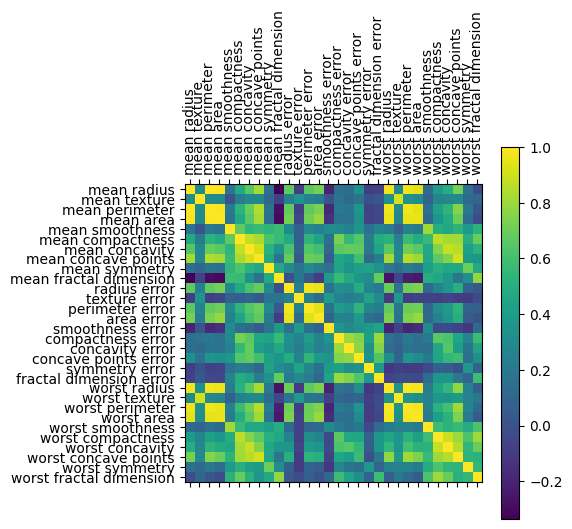

In [ ]:
# Visualize the correlation matrix
plt.matshow(corr_mat)
plt.xticks(range(len(corr_mat.columns)), corr_mat.columns, rotation=90)
plt.yticks(range(len(corr_mat.columns)), corr_mat.columns)
plt.colorbar()
plt.show()

## Class Distribution

In [ ]:
values, counts = np.unique(y_train, return_counts=True)
print(values)
print(counts)

['benign' 'malignant']
[286 169]


Begign is an over-represented class.

### Try it yourself (Cont. from Week 4, Tutorial 1)

*   Back in Tutorial 1 of Week 4, your task was to perform logistic regression over the Breast Cancer Wisconsin (Diagnostic) dataset. You must have performed some EDA over that data.
*   **Task**: Perform EDA over the data. Based on your analysis, execute feature selection, outlier treatment, and data visualization to improve the current SVM model's evaluation metric.












# 6.   Model Building: Training and Testing

Let us define an SVM model to perform the given classification task.

In [ ]:
#Import Support Vector Classifier class
from sklearn.svm import SVC
model = SVC(kernel='linear', random_state=42) #Define an object of SVC class

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set

Here, we are using a linear kernel.

# 7.   Results and Interpretation

Before we jump to te conclusion, one must understand the meaning of **positive class**.

*      In many classification evaluation metrics including precision, recall, and F1 score, a positive class typically refers to the class of interest or the class that is being predicted or detected by a model.

*      For example, in binary classification, if the task is to predict whether an email is spam or not, the positive class would be the class of spam emails. In this case, the evaluation metrics would focus on how well the model is able to correctly identify the spam emails, which is the positive class.


For our current case, the class of interest is the *malignant* class.

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix

# Print the evaluation metrics on train data
F1_train = f1_score(y_train, y_pred_train, pos_label='malignant') #Notice pos_label
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train F1 score: ", np.round(F1_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
F1 = f1_score(y_test, y_pred, pos_label='malignant')
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test F1 score: ", np.round(F1, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train F1 score:  0.982
Train confusion matrix: 
 [[283   3]
 [  3 166]]
Test F1 score:  0.943
Test confusion matrix: 
 [[68  3]
 [ 2 41]]


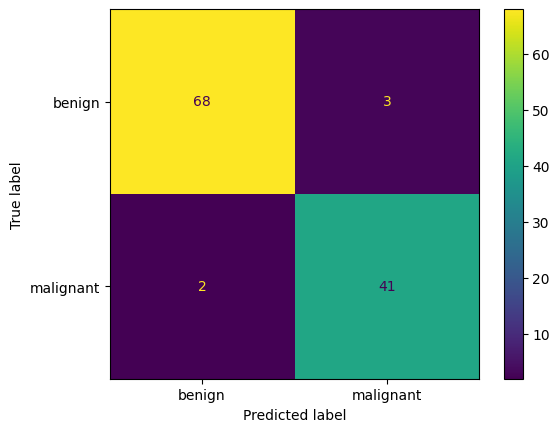

In [ ]:
#Another way of presenting the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels={'benign','malignant'}) #Positive = Class 1 = Malignant
disp.plot()
plt.show()

[[TN, FN],

[FP, TP]]

# Kernels

So far, we used linear kernel for the problem. Let us try with the other kernels and see how the results vary.

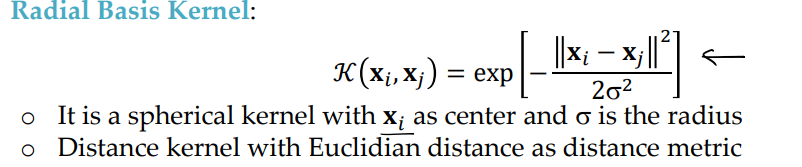

In [ ]:
#rbf Kernel
model = SVC(kernel='rbf', random_state=42) #Define an object of SVC class with polynomial kernel of degree 5 & offset (intercept) 1

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set


# Print the evaluation metrics on train data
F1_train = f1_score(y_train, y_pred_train, pos_label='malignant') #Notice pos_label
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train F1 score: ", np.round(F1_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
F1 = f1_score(y_test, y_pred, pos_label='malignant')
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test F1 score: ", np.round(F1, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train F1 score:  0.982
Train confusion matrix: 
 [[286   0]
 [  6 163]]
Test F1 score:  0.965
Test confusion matrix: 
 [[70  1]
 [ 2 41]]


The test resutls have improved.

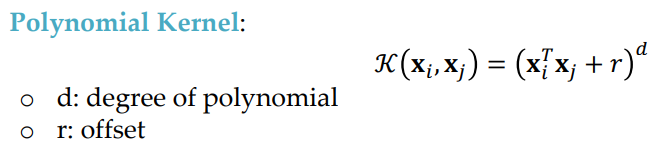

In scikit-learn, this translates to 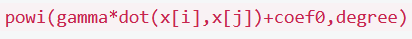

In [ ]:
#Polynomial Kernel:
d = 4
r = 1
g = 'scale' #1 / (n_features * X.var())
model = SVC(kernel='poly', degree=d, coef0=r, gamma=g, random_state=42) #Define an object of SVC class with polynomial kernel of degree 5 & offset (intercept) 1

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set


# Print the evaluation metrics on train data
F1_train = f1_score(y_train, y_pred_train, pos_label='malignant') #Notice pos_label
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train F1 score: ", np.round(F1_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
F1 = f1_score(y_test, y_pred, pos_label='malignant')
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test F1 score: ", np.round(F1, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train F1 score:  0.991
Train confusion matrix: 
 [[286   0]
 [  3 166]]
Test F1 score:  0.965
Test confusion matrix: 
 [[70  1]
 [ 2 41]]


Both train and test results have significantly improved.

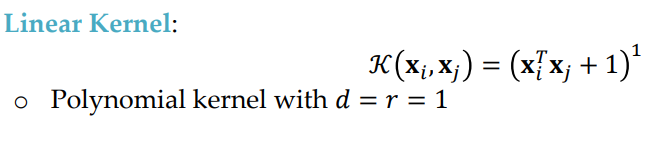

Let us test if we can use the polynomila kernel function for replicating the functionality of linear kernel.

In [ ]:
#Polynomial Kernel to Linear Kernel:
d = 1
r = 1
g = 1
model = SVC(kernel='poly', degree=d, coef0=r, gamma=g, random_state=42) #Define an object of SVC class with polynomial kernel of degree 5 & offset (intercept) 1

model.fit(X_train, y_train) #Training the model on train data
y_pred_train = model.predict(X_train) #Make predictions on the training set
y_pred = model.predict(X_test) #Make predictions on the testing set


# Print the evaluation metrics on train data
F1_train = f1_score(y_train, y_pred_train, pos_label='malignant') #Notice pos_label
confusion_mat_train = confusion_matrix(y_train, y_pred_train)
print("Evaluation metrics: Train Data")
print("Train F1 score: ", np.round(F1_train, decimals=3))
print("Train confusion matrix: \n", confusion_mat_train)

# Print the evaluation metrics on train data
F1 = f1_score(y_test, y_pred, pos_label='malignant')
confusion_mat = confusion_matrix(y_test, y_pred)
print("Test F1 score: ", np.round(F1, decimals=3))
print("Test confusion matrix: \n", confusion_mat)

Evaluation metrics: Train Data
Train F1 score:  0.982
Train confusion matrix: 
 [[283   3]
 [  3 166]]
Test F1 score:  0.943
Test confusion matrix: 
 [[68  3]
 [ 2 41]]


The results are the same as that of using a linear kernel directly.

# 8. Conclusion

A two class SVM classifier to classify whether a given tumor is malignant or benign based on the available features has been trained with a test F1 score of 0.965 for polynomial kernel with degree 4 and offset 1.

As described before **(Try it yourself)**, you can perform extensive EDA in order to improve the model performatnce further.

# 9.   Try it yourself excercise


*   **Problem Statement**: Perform SVM-based regression to predict the price (in INR) of mustard oil in India over time based on the available data.

*   **Task**: The Food Price India dataset provides information on food prices in India, which has been sourced from the World Food Programme Price Database (https://data.humdata.org/dataset/wfp-food-prices). The database covers a wide range of food items, including maize, rice, beans, oil, fish, and sugar, since 1994.  In total the dataset contains 172016 rows and 14 columns. The task is to intelligently extract mustard oil prices and train an SVM regression model that is able to predict the prices effectively. You are free to select the hyperparameters.

*  **Source**: https://www.kaggle.com/datasets/csafrit2/india-food-prices

**Hint**:

1.   Drop the irrelevant parameters.
2.   India is a huge country with big markets having varied prices for the same commodity at the same time. It is a design choice to select mean, median, max, mode, min, etc., statistical parameter for the price of a commodity accross the country.



In [ ]:
import pandas as pd
data = pd.read_csv("https://raw.githubusercontent.com/sachinmotwani20/NPTEL-ML_Datasets/main/food_prices_ind.csv")
data.head()

,date,admin1,admin2,market,latitude,longitude,category,commodity,unit,priceflag,pricetype,currency,price,usdprice
0,15-01-1994,Delhi,Delhi,Delhi,28.67,77.22,cereals and tubers,Rice,KG,actual,Retail,INR,8.0,0.2545
1,15-01-1994,Delhi,Delhi,Delhi,28.67,77.22,cereals and tubers,Wheat,KG,actual,Retail,INR,5.0,0.1590
2,15-01-1994,Delhi,Delhi,Delhi,28.67,77.22,miscellaneous food,Sugar,KG,actual,Retail,INR,13.5,0.4294
3,15-01-1994,Delhi,Delhi,Delhi,28.67,77.22,oil and fats,Oil (mustard),KG,actual,Retail,INR,31.0,0.9860
4,15-01-1994,Gujarat,Ahmadabad,Ahmedabad,23.03,72.62,cereals and tubers,Rice,KG,actual,Retail,INR,6.8,0.2163


# 10. Summary

In this module, we learned



*   To apply **Support Vector Classifcation** (SVC) over a public dataset
*   To use various **kernels** for **Support Vector Classifiers** (SVC)
*   Exercise: To apply **Support Vector Regression** (SVR) on a public dataset

